# Universität Osnabrück - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [6]:
client = bigquery.Client(project='subugoe-collaborative')

In [7]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Universität Osnabrück' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/04qmmjx98' -- 'Universität Osnabrück'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [8]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Universität Osnabrück,Institut für Kognitionswissenschaft. Osnabrück...,https://openalex.org/W4405521013
1,not assigned,Universität Osnabrück,Institut für Kognitionswissenschaft. Osnabrück...,https://openalex.org/W4405521013
2,not assigned,Universität Osnabrück,"Department of Dermatology, Environmental Medic...",https://openalex.org/W4401087626
3,not assigned,Universität Osnabrück,Institute for Interdisciplinary Dermatological...,https://openalex.org/W4401087626
4,not assigned,Universität Osnabrück,School of Biology and Chemistry and CellNanOs ...,https://openalex.org/W4403032620


In [2]:
MAPPING_DICT = {
    'Fachbereich Biologie / Chemie': ['dida(c|k)ti(k|cs) (of|der) (biolog(ie|y)|chemie)', 'genetics', 'biolog(ie|y)(/| and )chemi(e|stry)', 'botan(y|ical)', 
                                      '(new|organic|neuer) material(ien|s)', '(neuro|mi(k|c)ro)biolog(ie|y)', 'chemi(e|stry)', 'electrochemical',
                                      'bioorganische', '(behavio(u)?ral|structural|cell) biology', 'nanoanalytic', 'zoology', 
                                      'plant physiology', 'ecology', 'animal', '(department|faculty) of biology', 'bioimaging'
                                     ],
    'Fachbereich Erziehungs- und Kulturwissenschaften': ['education(al)? science', 'erziehungswissenschaft', '(school|science) of education', 
                                                         '(islami(sche|c)|katholische|ev.|evangelische) theolog(ie|y)', 'vocational',
                                                         'schulpädagogik', 'sport', 'elementary education', 'childhood', 
                                                        ],
    'Fachbereich Humanwissenschaften': ['kognitionswissenschaft', 'dermatolog(ie|ic|y|ische)', 'psycholog(ie|y)', 'cognitive', '(human|health) (sciences|research)',
                                        'pflegewissenschaft', 'philosophy', 'ethics and critical theories', 'new public health', 'psychotherapy',
                                        'gesundheitsforschung'
                                       ],
    'Fachbereich Kultur- und Sozialwissenschaften': ['social sciences', 'geograph(ie|y)', 'sozial(- und kultur)?wissenschaften', 'european integration',
                                                     'music', 'conflict research', 'historisches seminar', 'department of history', 'modern history',
                                                     'neueste geschichte'
                                                    ],
    'Fachbereich Mathematik / Informatik / Physik': ['mathemati(k|cs)', '(institut|department) (für|of) (physi(k|cs)|informatik)', 'computer science', 'physi(k|cs),',
                                                     'semantic information', 'data science', 'information systems', 'digital image', 'fachbereich physik',
                                                     'software engineering', 'physics (education|department)', 'computer engineering', 'knowledge-based systems',
                                                     'artificial intelligence'
                                                    ],
    'Fachbereich Rechtswissenschaften': ['(gesellschafts|straf|völker|europa|wirtschafts)recht', 'faculty of law', 'legal studies'],
    'Fachbereich Sprach- und Literaturwissenschaft': ['germanistik', 'linguistics', 'american studies', 'latinistics', 'romance studies'],
    'Fachbereich Wirtschaftswissenschaften': ['wirtschaftsinformatik', 'business administration', 'accounting', 'economic education', 'business and economics',
                                              'wirtschaftswissenschaften', 'banking and finance', '(international|empirical) economic', 'department of economics',
                                              'innovation management'
                                             ],
    'Institut für Migrationsforschung und Interkulturelle Studien (IMIS)': ['(imis)', 'migrationsforschung', 'migration research'],
    'Institut für Umweltsystemforschung': ['environmental systems (science|research|economics)'],
    #'Universitätsbibliothek': [],
    #'Zentrum für Informationsmanagement und Virtuelle Lehre': [],
    #'Zentrum für Lehrerbildung (ZLB)': []
}

In [3]:
with open('./mapping_tables_fak/uosnabrueck.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [1065]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [1066]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [1067]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Fachbereich Humanwissenschaften,Universität Osnabrück,Institut für Kognitionswissenschaft. Osnabrück...,https://openalex.org/W4405521013
1,Fachbereich Humanwissenschaften,Universität Osnabrück,Institut für Kognitionswissenschaft. Osnabrück...,https://openalex.org/W4405521013
2,Fachbereich Humanwissenschaften,Universität Osnabrück,"Department of Dermatology, Environmental Medic...",https://openalex.org/W4401087626
3,Fachbereich Humanwissenschaften,Universität Osnabrück,Institute for Interdisciplinary Dermatological...,https://openalex.org/W4401087626
4,Fachbereich Biologie / Chemie,Universität Osnabrück,School of Biology and Chemistry and CellNanOs ...,https://openalex.org/W4403032620
...,...,...,...,...
5316,None,Universität Osnabrück,Universität Osnabrück Deutschland,https://openalex.org/W3155073290
5317,None,Universität Osnabrück,Universität Osnabrück Deutschland,https://openalex.org/W4236870157
5318,None,Universität Osnabrück,Universität Osnabrück Deutschland,https://openalex.org/W4234081034
5319,None,Universität Osnabrück,Universität Osnabrück Deutschland,https://openalex.org/W3155867903


In [1068]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()[200:220]

array(['Osnabrück University, Barbarastraße 7, D-49076 Osnabrück, Germany',
       'Univ. Osnabrück (Germany)',
       'Osnabrück University, 49069 Osnabrück, Germany',
       'Epilepsy Center Münster-Osnabrück, Department of Neurology with Institute of Translational Neurology, Westfälische Wilhelms-University, Münster, Germany; Department of Neurology, Klinikum Osnabrück, Osnabrück, Germany',
       'Department of Neurology and Neurorehabilitation Klinikum, Osnabrück, Academic Teaching Hospital of the Westfälische Wilhelms-University of Münster, Osnabrück, Germany',
       'Universität Osnabrück, MTDML, Niedersachsen, Germany',
       'University of Osnabrück, Osnabruck, Germany',
       'Plan-based Robot Control, DFKI Niedersachsen, 49080 OsnabrÃ¼ck, Germany',
       'Knowledge Based Systems Group, OsnabrÃ¼ck University, 49080 OsnabrÃ¼ck, Germany',
       'Plan-based Robot Control, DFKI Niedersachsen, 49080 Osnabrück, Germany',
       'Knowledge Based Systems Group, Osnabrück Univers

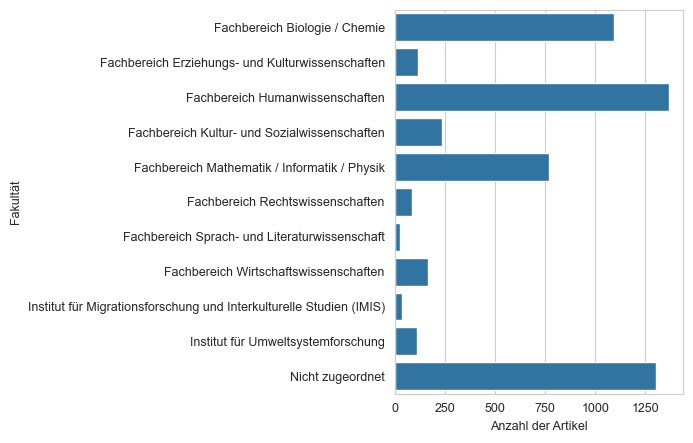

In [1069]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [1070]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.7547453486186807